# Multilabel metrics dashboard for the 1000-news manual dataset

This notebook evaluates the classifier against the new wide multilabel dataset.

The old single-label metric is not the right headline for this task: one news item can have several relevant
factors, and 13 of 36 factors may have zero support in a given 1000-row evaluation set.

Recommended dashboard:
- `factor_micro_f1`: main operational metric over all factor decisions.
- `sample_f1_empty_correct`: per-news factor-set F1, with empty/empty treated as correct.
- `any_relevant_f1`: relevance gate quality, meaning whether a news item has at least one relevant factor.
- `supported_macro_f1`: class-balance diagnostic over factors present in the dataset.
- `exact_match`: strict diagnostic, useful but intentionally not the headline.

In [1]:
from __future__ import annotations

import json
import math
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    hamming_loss,
    precision_recall_fscore_support,
)

ROOT = Path.cwd()
if not (ROOT / "manage.py").exists():
    ROOT = Path(r"C:\Users\whynot\VSCodeProjects\news-zero-shot")
sys.path.insert(0, str(ROOT))

DATASET_CANDIDATES = [
    ROOT / "interfax_news_multilabel_factor_dataset_1000_wide.csv",
    ROOT / "analysis_outputs" / "interfax_news_multilabel_factor_dataset_1000_wide.csv",
    Path(r"C:\Users\whynot\Downloads\interfax_news_multilabel_factor_dataset_1000_wide.csv"),
]
DATASET_PATH = next((path for path in DATASET_CANDIDATES if path.exists()), None)
if DATASET_PATH is None:
    raise FileNotFoundError("Cannot find interfax_news_multilabel_factor_dataset_1000_wide.csv")

OUTPUT_DIR = ROOT / "analysis_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

LLM_PREDICTIONS_PATH = OUTPUT_DIR / "manual_dataset_prompt_search_best_balanced_recall_v2.csv"
if not LLM_PREDICTIONS_PATH.exists():
    raise FileNotFoundError(f"Missing LLM predictions: {LLM_PREDICTIONS_PATH}")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 140)
pd.set_option("display.max_colwidth", 180)

print(f"root={ROOT}")
print(f"dataset={DATASET_PATH}")
print(f"llm_predictions={LLM_PREDICTIONS_PATH}")

root=C:\Users\whynot\VSCodeProjects\news-zero-shot
dataset=C:\Users\whynot\Downloads\interfax_news_multilabel_factor_dataset_1000_wide.csv
llm_predictions=C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\manual_dataset_prompt_search_best_balanced_recall_v2.csv


## 1. Load and validate the wide multilabel dataset

In [2]:
from analyzer.factors import FACTOR_CONFIG

factor_keys = [item["key"] for item in FACTOR_CONFIG]
factor_names = {item["key"]: item["name"] for item in FACTOR_CONFIG}

def cyrillic_count(text: str) -> int:
    return sum(1 for char in text if 0x0400 <= ord(char) <= 0x04FF)

raw_bytes = DATASET_PATH.read_bytes()
dataset_encoding = {
    "bytes": len(raw_bytes),
    "bom_utf8": raw_bytes.startswith(b"\xef\xbb\xbf"),
    "utf8_ok": True,
    "replacement_chars": 0,
}
try:
    decoded = raw_bytes.decode("utf-8-sig")
    dataset_encoding["replacement_chars"] = decoded.count("\ufffd")
    dataset_encoding["cyrillic_chars"] = cyrillic_count(decoded)
except UnicodeDecodeError as exc:
    dataset_encoding["utf8_ok"] = False
    dataset_encoding["utf8_error"] = str(exc)
    raise

df = pd.read_csv(DATASET_PATH, encoding="utf-8-sig")
row_id_col = "Номер строки в датасете 1000"
if row_id_col not in df.columns:
    row_id_col = df.columns[0]
df["dataset_row_id"] = pd.to_numeric(df[row_id_col], errors="raise").astype(int)

expected_factor_cols = [f"factor__{key}" for key in factor_keys]
missing_factor_cols = [col for col in expected_factor_cols if col not in df.columns]
extra_factor_cols = sorted(
    col.replace("factor__", "")
    for col in df.columns
    if col.startswith("factor__") and col.replace("factor__", "") not in factor_keys
)
if missing_factor_cols:
    raise ValueError(f"Missing factor columns: {missing_factor_cols}")
if extra_factor_cols:
    raise ValueError(f"Unexpected factor columns: {extra_factor_cols}")

Y = np.column_stack(
    [
        pd.to_numeric(df[f"factor__{key}"], errors="coerce")
        .fillna(0)
        .astype(int)
        .clip(0, 1)
        .to_numpy()
        for key in factor_keys
    ]
)
ids = df["dataset_row_id"].to_numpy()
true_label_count = Y.sum(axis=1)
factor_support = pd.Series(Y.sum(axis=0), index=factor_keys).sort_values(ascending=False)
supported_factor_keys = [key for key in factor_keys if factor_support[key] > 0]
head_factor_keys = [key for key in factor_keys if factor_support[key] >= 25]

relevant_count_col = "Количество релевантных факторов"
relevant_count_mismatch = None
if relevant_count_col in df.columns:
    declared = pd.to_numeric(df[relevant_count_col], errors="coerce").fillna(0).astype(int).to_numpy()
    relevant_count_mismatch = int((declared != true_label_count).sum())

dataset_stats = {
    "rows": int(len(df)),
    "columns": int(len(df.columns)),
    "factor_count": int(len(factor_keys)),
    "positive_factor_pairs": int(Y.sum()),
    "not_relevant_news": int((true_label_count == 0).sum()),
    "relevant_news": int((true_label_count > 0).sum()),
    "multi_label_news": int((true_label_count > 1).sum()),
    "supported_factor_count": int((factor_support > 0).sum()),
    "zero_support_factor_count": int((factor_support == 0).sum()),
    "mean_labels_per_news": float(true_label_count.mean()),
    "mean_labels_per_relevant_news": float(true_label_count[true_label_count > 0].mean()),
    "relevant_count_mismatch": relevant_count_mismatch,
}

print(json.dumps(dataset_encoding, ensure_ascii=False, indent=2))
print(json.dumps(dataset_stats, ensure_ascii=False, indent=2))
display(pd.Series(true_label_count).value_counts().sort_index().rename("news_count").to_frame())
display(factor_support.rename("support").to_frame())

{
  "bytes": 5903801,
  "bom_utf8": true,
  "utf8_ok": true,
  "replacement_chars": 0,
  "cyrillic_chars": 1769120
}
{
  "rows": 1000,
  "columns": 215,
  "factor_count": 36,
  "positive_factor_pairs": 915,
  "not_relevant_news": 275,
  "relevant_news": 725,
  "multi_label_news": 182,
  "supported_factor_count": 23,
  "zero_support_factor_count": 13,
  "mean_labels_per_news": 0.915,
  "mean_labels_per_relevant_news": 1.2620689655172415,
  "relevant_count_mismatch": 0
}


,news_count
0,275
1,543
2,174
3,8


,support
crime_count,244
industrial_production_index,206
enterprises_count,157
consumer_price_index,66
mortality_rate,44
life_expectancy,41
air_pollution,37
international_inflow,28
housing_area_per_capita,20
per_capita_income,16


## 2. Label distribution EDA

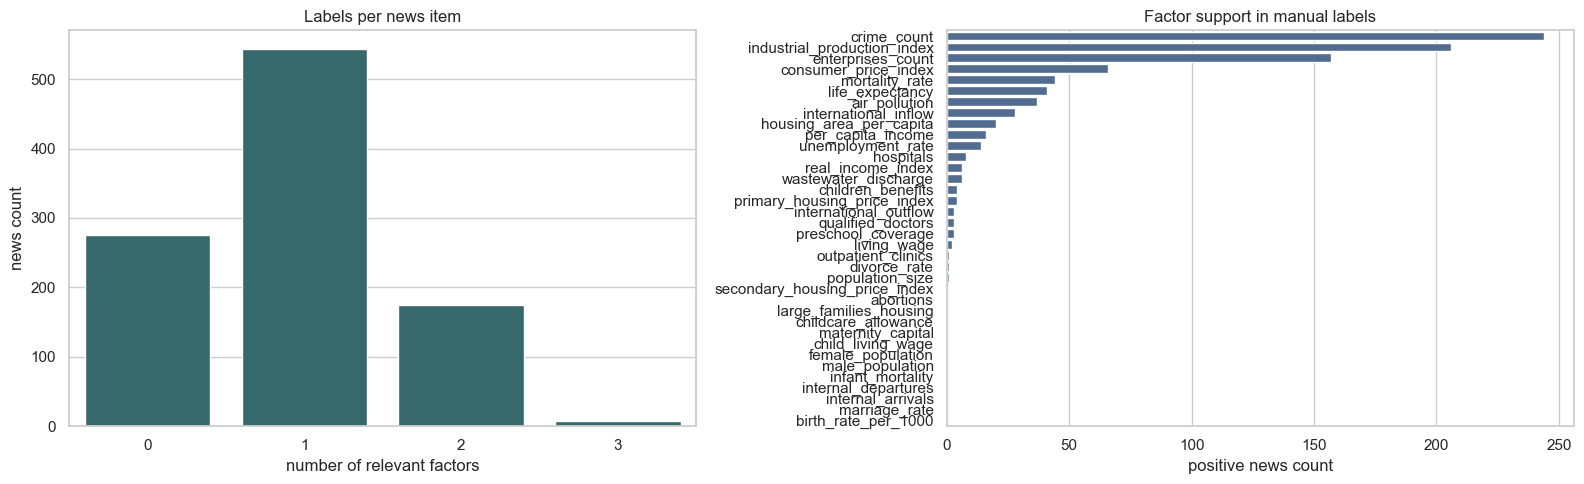

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

label_count_dist = pd.Series(true_label_count).value_counts().sort_index()
sns.barplot(x=label_count_dist.index.astype(str), y=label_count_dist.values, ax=axes[0], color="#2f6f73")
axes[0].set_title("Labels per news item")
axes[0].set_xlabel("number of relevant factors")
axes[0].set_ylabel("news count")

support_plot = factor_support.reset_index()
support_plot.columns = ["factor", "support"]
sns.barplot(data=support_plot, y="factor", x="support", ax=axes[1], color="#486a9a")
axes[1].set_title("Factor support in manual labels")
axes[1].set_xlabel("positive news count")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## 3. Load LLM predictions and align matrices

In [4]:
pred_long = pd.read_csv(LLM_PREDICTIONS_PATH, encoding="utf-8-sig")
if pred_long["is_relevant"].dtype == object:
    pred_long["is_relevant_bool"] = pred_long["is_relevant"].astype(str).str.lower().isin(["true", "1", "yes"])
else:
    pred_long["is_relevant_bool"] = pred_long["is_relevant"].astype(bool)
pred_long["relevance"] = pd.to_numeric(pred_long["relevance"], errors="coerce").fillna(0.0)

pred_factor_keys = sorted(pred_long["factor_key"].dropna().astype(str).unique())
prediction_integrity = {
    "rows": int(len(pred_long)),
    "expected_rows": int(len(df) * len(factor_keys)),
    "news_id_count": int(pred_long["dataset_row_id"].nunique()),
    "factor_key_count": int(len(pred_factor_keys)),
    "missing_factor_keys": [key for key in factor_keys if key not in pred_factor_keys],
    "extra_factor_keys": sorted(set(pred_factor_keys) - set(factor_keys)),
    "duplicate_news_factor_rows": int(pred_long.duplicated(["dataset_row_id", "factor_key"]).sum()),
}
print(json.dumps(prediction_integrity, ensure_ascii=False, indent=2))

score_matrix = (
    pred_long.pivot(index="dataset_row_id", columns="factor_key", values="relevance")
    .reindex(index=ids, columns=factor_keys)
    .fillna(0.0)
    .to_numpy(float)
)
default_pred_matrix = (
    pred_long.pivot(index="dataset_row_id", columns="factor_key", values="is_relevant_bool")
    .reindex(index=ids, columns=factor_keys)
    .fillna(False)
    .astype(bool)
    .to_numpy(int)
)

print(f"score_matrix={score_matrix.shape}, default_pred_matrix={default_pred_matrix.shape}")

{
  "rows": 36000,
  "expected_rows": 36000,
  "news_id_count": 1000,
  "factor_key_count": 36,
  "missing_factor_keys": [],
  "extra_factor_keys": [],
  "duplicate_news_factor_rows": 0
}
score_matrix=(1000, 36), default_pred_matrix=(1000, 36)


## 4. Multilabel metric definitions

In [5]:
def per_sample_f1_empty_correct(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    intersection = (y_true & y_pred).sum(axis=1)
    true_count = y_true.sum(axis=1)
    pred_count = y_pred.sum(axis=1)
    denom = true_count + pred_count
    values = np.where(denom == 0, 1.0, 2 * intersection / np.maximum(denom, 1))
    return float(values.mean())

def per_sample_jaccard_empty_correct(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    intersection = (y_true & y_pred).sum(axis=1)
    union = (y_true | y_pred).sum(axis=1)
    values = np.where(union == 0, 1.0, intersection / np.maximum(union, 1))
    return float(values.mean())

def evaluate_matrix(y_pred: np.ndarray, name: str) -> dict:
    y_pred = y_pred.astype(int)
    supported_idx = [factor_keys.index(key) for key in supported_factor_keys]
    head_idx = [factor_keys.index(key) for key in head_factor_keys]

    y_any = (Y.sum(axis=1) > 0).astype(int)
    p_any = (y_pred.sum(axis=1) > 0).astype(int)
    any_precision, any_recall, any_f1, _ = precision_recall_fscore_support(
        y_any,
        p_any,
        average="binary",
        zero_division=0,
    )
    empty_specificity = (
        ((y_any == 0) & (p_any == 0)).sum() / max(1, (y_any == 0).sum())
    )

    micro_precision, micro_recall, micro_f1, _ = precision_recall_fscore_support(
        Y,
        y_pred,
        average="micro",
        zero_division=0,
    )

    return {
        "name": name,
        "pred_positive_pairs": int(y_pred.sum()),
        "pred_relevant_news": int(p_any.sum()),
        "mean_pred_labels_per_news": float(y_pred.sum(axis=1).mean()),
        "exact_match": float((Y == y_pred).all(axis=1).mean()),
        "sample_f1_empty_correct": per_sample_f1_empty_correct(Y, y_pred),
        "sample_jaccard_empty_correct": per_sample_jaccard_empty_correct(Y, y_pred),
        "factor_micro_f1": float(micro_f1),
        "factor_micro_precision": float(micro_precision),
        "factor_micro_recall": float(micro_recall),
        "factor_macro_f1_all36": float(f1_score(Y, y_pred, average="macro", zero_division=0)),
        "factor_macro_f1_supported": float(
            f1_score(Y[:, supported_idx], y_pred[:, supported_idx], average="macro", zero_division=0)
        ),
        "factor_macro_f1_head_ge25": float(
            f1_score(Y[:, head_idx], y_pred[:, head_idx], average="macro", zero_division=0)
            if head_idx
            else 0.0
        ),
        "factor_weighted_f1": float(f1_score(Y, y_pred, average="weighted", zero_division=0)),
        "hamming_loss": float(hamming_loss(Y, y_pred)),
        "any_relevant_precision": float(any_precision),
        "any_relevant_recall": float(any_recall),
        "any_relevant_f1": float(any_f1),
        "empty_specificity": float(empty_specificity),
    }

metric_columns = [
    "name",
    "sample_f1_empty_correct",
    "sample_jaccard_empty_correct",
    "factor_micro_f1",
    "factor_micro_precision",
    "factor_micro_recall",
    "factor_macro_f1_supported",
    "factor_macro_f1_head_ge25",
    "factor_weighted_f1",
    "exact_match",
    "any_relevant_f1",
    "any_relevant_precision",
    "any_relevant_recall",
    "empty_specificity",
    "mean_pred_labels_per_news",
    "pred_positive_pairs",
]

## 5. Threshold sweep and recommended dashboard

,name,sample_f1_empty_correct,sample_jaccard_empty_correct,factor_micro_f1,factor_micro_precision,factor_micro_recall,factor_macro_f1_supported,factor_macro_f1_head_ge25,factor_weighted_f1,exact_match,any_relevant_f1,any_relevant_precision,any_relevant_recall,empty_specificity,mean_pred_labels_per_news,pred_positive_pairs
3,threshold_0.15,0.4879,0.4662,0.4888,0.5300,0.4536,0.2605,0.3841,0.4684,0.404,0.8089,0.7949,0.8234,0.4400,0.783,783
4,threshold_0.20,0.4879,0.4662,0.4888,0.5300,0.4536,0.2605,0.3841,0.4684,0.404,0.8089,0.7949,0.8234,0.4400,0.783,783
5,threshold_0.25,0.4879,0.4662,0.4888,0.5300,0.4536,0.2605,0.3841,0.4684,0.404,0.8089,0.7949,0.8234,0.4400,0.783,783
6,threshold_0.30,0.4879,0.4662,0.4888,0.5300,0.4536,0.2605,0.3841,0.4684,0.404,0.8089,0.7949,0.8234,0.4400,0.783,783
23,top2_positive_score,0.4861,0.4644,0.4879,0.5280,0.4536,0.2603,0.3836,0.4675,0.402,0.8095,0.7934,0.8262,0.4327,0.786,786
1,threshold_0.05,0.4859,0.4642,0.4877,0.5273,0.4536,0.2602,0.3831,0.4673,0.402,0.8095,0.7934,0.8262,0.4327,0.787,787
2,threshold_0.10,0.4859,0.4642,0.4877,0.5273,0.4536,0.2602,0.3831,0.4673,0.402,0.8095,0.7934,0.8262,0.4327,0.787,787
25,top3_positive_score,0.4859,0.4642,0.4877,0.5273,0.4536,0.2602,0.3831,0.4673,0.402,0.8095,0.7934,0.8262,0.4327,0.787,787
27,top5_positive_score,0.4859,0.4642,0.4877,0.5273,0.4536,0.2602,0.3831,0.4673,0.402,0.8095,0.7934,0.8262,0.4327,0.787,787
29,top10_positive_score,0.4859,0.4642,0.4877,0.5273,0.4536,0.2602,0.3831,0.4673,0.402,0.8095,0.7934,0.8262,0.4327,0.787,787


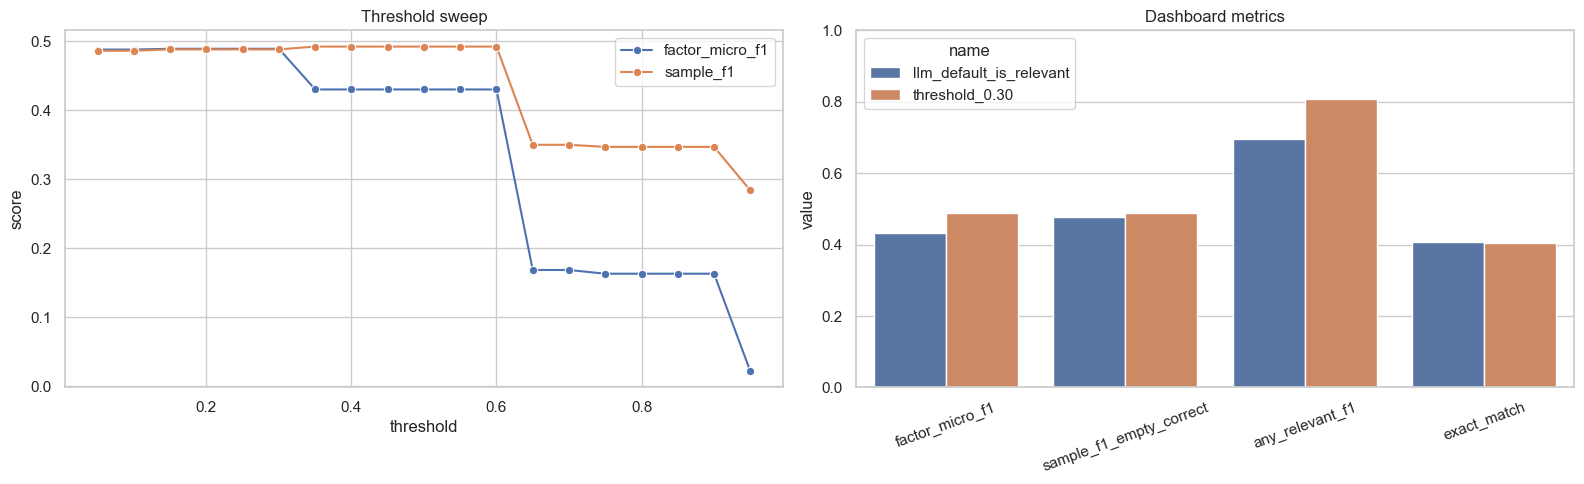

recommended_threshold_variant=threshold_0.30


,value
name,threshold_0.30
sample_f1_empty_correct,0.4879
sample_jaccard_empty_correct,0.46625
factor_micro_f1,0.48881
factor_micro_precision,0.530013
factor_micro_recall,0.453552
factor_macro_f1_supported,0.260526
factor_macro_f1_head_ge25,0.384145
factor_weighted_f1,0.46841
exact_match,0.404


In [6]:
rows = [evaluate_matrix(default_pred_matrix, "llm_default_is_relevant")]

for threshold in np.round(np.arange(0.05, 0.96, 0.05), 2):
    rows.append(evaluate_matrix((score_matrix >= threshold).astype(int), f"threshold_{threshold:.2f}"))

for k in [1, 2, 3, 5, 10]:
    forced = np.zeros_like(Y)
    order = np.argsort(-score_matrix, axis=1)[:, :k]
    for row_idx, factor_idx in enumerate(order):
        forced[row_idx, factor_idx] = 1
    rows.append(evaluate_matrix(forced, f"top{k}_forced"))

    positive_only = np.zeros_like(Y)
    for row_idx, factor_idx in enumerate(order):
        for idx in factor_idx:
            if score_matrix[row_idx, idx] > 0:
                positive_only[row_idx, idx] = 1
    rows.append(evaluate_matrix(positive_only, f"top{k}_positive_score"))

metrics = pd.DataFrame(rows)
threshold_metrics = metrics[metrics["name"].str.startswith("threshold_")].copy()
default_metrics = metrics[metrics["name"] == "llm_default_is_relevant"].copy()

# Primary recommendation: maximize factor_micro_f1; if tied, prefer the default threshold-like behavior.
max_micro = threshold_metrics["factor_micro_f1"].max()
best_threshold_candidates = threshold_metrics[np.isclose(threshold_metrics["factor_micro_f1"], max_micro)].copy()
if "threshold_0.30" in set(best_threshold_candidates["name"]):
    best_row = best_threshold_candidates[best_threshold_candidates["name"] == "threshold_0.30"].iloc[0]
else:
    best_row = best_threshold_candidates.sort_values("sample_f1_empty_correct", ascending=False).iloc[0]

display(metrics[metric_columns].sort_values(["factor_micro_f1", "sample_f1_empty_correct"], ascending=False).round(4).head(20))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
threshold_plot = threshold_metrics.copy()
threshold_plot["threshold"] = threshold_plot["name"].str.replace("threshold_", "", regex=False).astype(float)
sns.lineplot(data=threshold_plot, x="threshold", y="factor_micro_f1", marker="o", ax=axes[0], label="factor_micro_f1")
sns.lineplot(data=threshold_plot, x="threshold", y="sample_f1_empty_correct", marker="o", ax=axes[0], label="sample_f1")
axes[0].set_title("Threshold sweep")
axes[0].set_ylabel("score")

dashboard_names = ["llm_default_is_relevant", best_row["name"]]
dashboard_plot = metrics[metrics["name"].isin(dashboard_names)].melt(
    id_vars=["name"],
    value_vars=["factor_micro_f1", "sample_f1_empty_correct", "any_relevant_f1", "exact_match"],
    var_name="metric",
    value_name="value",
)
sns.barplot(data=dashboard_plot, x="metric", y="value", hue="name", ax=axes[1])
axes[1].set_title("Dashboard metrics")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print(f"recommended_threshold_variant={best_row['name']}")
display(best_row[metric_columns].to_frame("value"))

## 6. Top-k coverage diagnostics

,k,label_recall_at_k_on_relevant_news,news_hit_any_at_k_on_relevant_news,precision_at_k_all_news
0,1,0.4736,0.5572,0.4040
1,2,0.4860,0.5710,0.2080
2,3,0.4892,0.5738,0.1403
3,5,0.4899,0.5738,0.0844
4,10,0.5255,0.6138,0.0461
5,15,0.8805,0.9297,0.0521


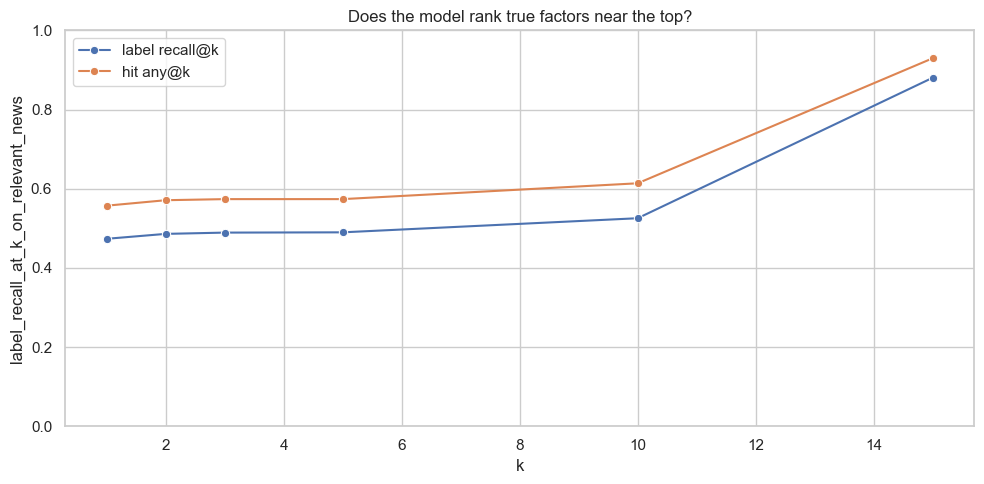

In [7]:
def topk_stats(k: int) -> dict:
    order = np.argsort(-score_matrix, axis=1)[:, :k]
    label_recalls = []
    hit_any = []
    precisions = []
    for row_idx, factor_idx in enumerate(order):
        true_set = set(np.where(Y[row_idx] == 1)[0])
        pred_set = set(factor_idx)
        if true_set:
            label_recalls.append(len(true_set & pred_set) / len(true_set))
            hit_any.append(1.0 if true_set & pred_set else 0.0)
        precisions.append(len(true_set & pred_set) / k)
    return {
        "k": k,
        "label_recall_at_k_on_relevant_news": float(np.mean(label_recalls)),
        "news_hit_any_at_k_on_relevant_news": float(np.mean(hit_any)),
        "precision_at_k_all_news": float(np.mean(precisions)),
    }

topk_results = pd.DataFrame([topk_stats(k) for k in [1, 2, 3, 5, 10, 15]])
display(topk_results.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=topk_results, x="k", y="label_recall_at_k_on_relevant_news", marker="o", ax=ax, label="label recall@k")
sns.lineplot(data=topk_results, x="k", y="news_hit_any_at_k_on_relevant_news", marker="o", ax=ax, label="hit any@k")
ax.set_title("Does the model rank true factors near the top?")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 7. Factor-level report for the recommended threshold

,factor_key,factor_name,support,predicted_positive,precision,recall,f1
31,crime_count,Количество преступлений,244,125,0.7840,0.4016,0.5312
29,industrial_production_index,Индексы промышленного производства,206,248,0.5806,0.6990,0.6344
30,enterprises_count,Число предприятий и организаций,157,99,0.7576,0.4777,0.5859
26,consumer_price_index,Индексы потребительских цен,66,102,0.5000,0.7727,0.6071
34,mortality_rate,Коэффициент смертности на 1000 человек,44,5,0.0000,0.0000,0.0000
8,life_expectancy,Ожидаемая продолжительность жизни,41,1,1.0000,0.0244,0.0476
32,air_pollution,Выбросы загрязняющих веществ в атмосферный воздух,37,30,0.4000,0.3243,0.3582
3,international_inflow,Число прибывших в страну,28,121,0.1901,0.8214,0.3087
25,housing_area_per_capita,Общая площадь жилья на одного жителя,20,1,0.0000,0.0000,0.0000
11,per_capita_income,Среднедушевые денежные доходы населения,16,1,1.0000,0.0625,0.1176


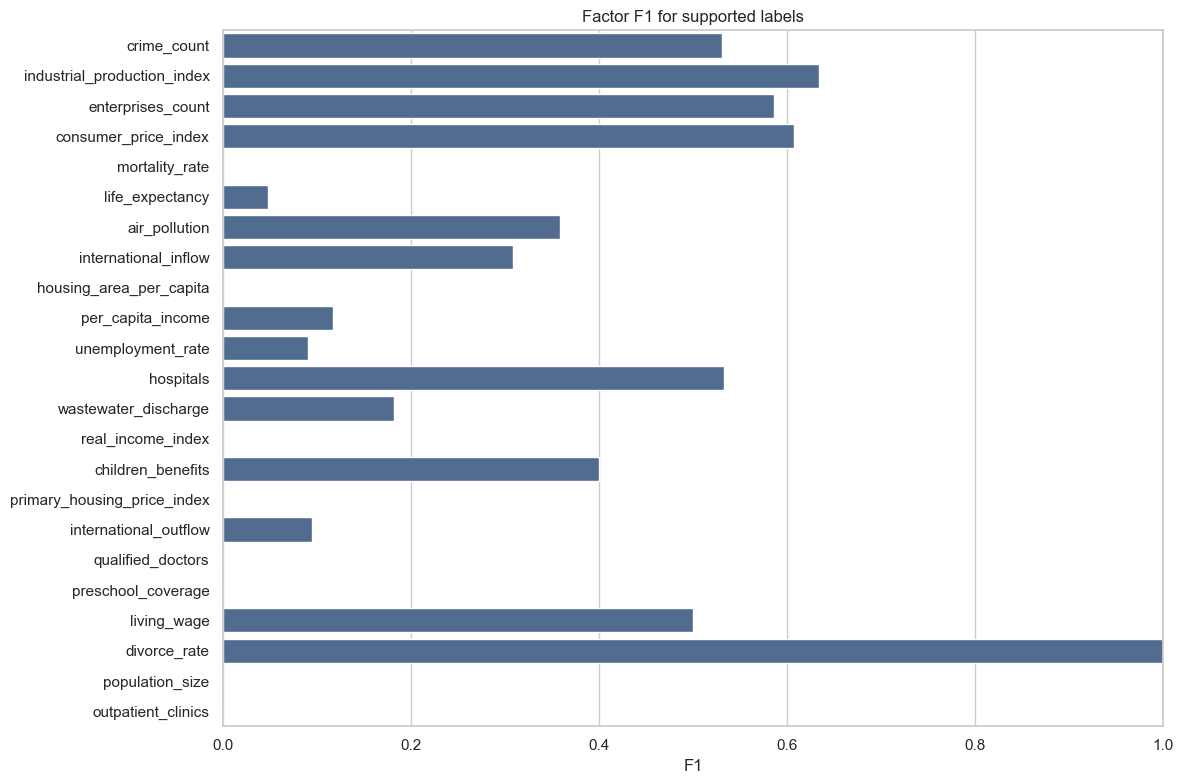

In [8]:
recommended_pred = (score_matrix >= float(str(best_row["name"]).replace("threshold_", ""))).astype(int)

precision, recall, f1, support = precision_recall_fscore_support(
    Y,
    recommended_pred,
    average=None,
    zero_division=0,
)
factor_report = pd.DataFrame(
    {
        "factor_key": factor_keys,
        "factor_name": [factor_names[key] for key in factor_keys],
        "support": support.astype(int),
        "predicted_positive": recommended_pred.sum(axis=0).astype(int),
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }
).sort_values(["support", "f1"], ascending=[False, False])

display(factor_report.round(4))

fig, ax = plt.subplots(figsize=(12, 8))
plot_df = factor_report[factor_report["support"] > 0].copy()
sns.barplot(data=plot_df, y="factor_key", x="f1", ax=ax, color="#486a9a")
ax.set_title("Factor F1 for supported labels")
ax.set_xlabel("F1")
ax.set_ylabel("")
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

## 8. News-level error table

In [9]:
def factors_from_vector(vector: np.ndarray) -> list[str]:
    return [factor_keys[idx] for idx in np.where(vector == 1)[0]]

error_rows = []
for row_idx, dataset_row_id in enumerate(ids):
    true_set = set(factors_from_vector(Y[row_idx]))
    pred_set = set(factors_from_vector(recommended_pred[row_idx]))
    tp = sorted(true_set & pred_set)
    fp = sorted(pred_set - true_set)
    fn = sorted(true_set - pred_set)
    union = true_set | pred_set
    jaccard = 1.0 if not union else len(true_set & pred_set) / len(union)
    sample_f1 = 1.0 if not (true_set or pred_set) else 2 * len(tp) / max(1, len(true_set) + len(pred_set))
    error_rows.append(
        {
            "dataset_row_id": int(dataset_row_id),
            "title": df.iloc[row_idx]["Заголовок новости"] if "Заголовок новости" in df.columns else "",
            "true_factors": ";".join(sorted(true_set)),
            "pred_factors": ";".join(sorted(pred_set)),
            "tp_factors": ";".join(tp),
            "fp_factors": ";".join(fp),
            "fn_factors": ";".join(fn),
            "true_count": len(true_set),
            "pred_count": len(pred_set),
            "sample_f1": sample_f1,
            "sample_jaccard": jaccard,
            "needs_review": bool(fp or fn),
        }
    )

news_errors = pd.DataFrame(error_rows).sort_values(["sample_f1", "true_count"], ascending=[True, False])
display(news_errors.head(30))

,dataset_row_id,title,true_factors,pred_factors,tp_factors,fp_factors,fn_factors,true_count,pred_count,sample_f1,sample_jaccard,needs_review
20,21,В Херсонской области в результате обстрела ранены водитель и врач скорой помощи,crime_count;hospitals;qualified_doctors,,,,crime_count;hospitals;qualified_doctors,3,0,0.0,0.0,True
6,7,Женщина погибла в результате атаки беспилотников ВСУ на населенный пункт Вахрушево в ЛНР,crime_count;mortality_rate,,,,crime_count;mortality_rate,2,0,0.0,0.0,True
15,16,Состояние пострадавших при ЧП в Курской области сотрудников РЖД удовлетворительное,life_expectancy;mortality_rate,hospitals,,hospitals,life_expectancy;mortality_rate,2,1,0.0,0.0,True
38,39,"В Турции заявили, что танкер Virat подвергся повторной атаке в Черном море",air_pollution;crime_count,international_outflow,,international_outflow,air_pollution;crime_count,2,1,0.0,0.0,True
52,53,"Что произошло за день: понедельник, 1 декабря",international_inflow;life_expectancy,crime_count,,crime_count,international_inflow;life_expectancy,2,1,0.0,0.0,True
120,121,Проект о передаче под контроль ЦБ регулирования сервисов покупок в рассрочку принят в I чтении,per_capita_income;real_income_index,consumer_price_index,,consumer_price_index,per_capita_income;real_income_index,2,1,0.0,0.0,True
128,129,"Что произошло за день: вторник, 13 мая",air_pollution;crime_count,international_inflow,,international_inflow,air_pollution;crime_count,2,1,0.0,0.0,True
139,140,"Что произошло за день: четверг, 3 апреля",consumer_price_index;mortality_rate,crime_count;industrial_production_index,,crime_count;industrial_production_index,consumer_price_index;mortality_rate,2,2,0.0,0.0,True
144,145,Госдума утвердила отчет об исполнении бюджетов ФОМС и Социального фонда за 2024 год,children_benefits;hospitals,,,,children_benefits;hospitals,2,0,0.0,0.0,True
158,159,"""АвтоВАЗ"" возобновил производство после корпоративного отпуска и майских праздников",industrial_production_index;unemployment_rate,enterprises_count,,enterprises_count,industrial_production_index;unemployment_rate,2,1,0.0,0.0,True


## 9. Save outputs and final reading

In [10]:
output_paths = {
    "summary": OUTPUT_DIR / "manual_dataset_multilabel_metrics_summary.json",
    "dashboard_metrics": OUTPUT_DIR / "manual_dataset_multilabel_dashboard_metrics.csv",
    "threshold_sweep": OUTPUT_DIR / "manual_dataset_multilabel_threshold_sweep.csv",
    "topk_results": OUTPUT_DIR / "manual_dataset_multilabel_topk_results.csv",
    "factor_report": OUTPUT_DIR / "manual_dataset_multilabel_factor_report.csv",
    "news_errors": OUTPUT_DIR / "manual_dataset_multilabel_news_errors.csv",
}

metrics.to_csv(output_paths["dashboard_metrics"], index=False, encoding="utf-8-sig")
threshold_metrics.to_csv(output_paths["threshold_sweep"], index=False, encoding="utf-8-sig")
topk_results.to_csv(output_paths["topk_results"], index=False, encoding="utf-8-sig")
factor_report.to_csv(output_paths["factor_report"], index=False, encoding="utf-8-sig")
news_errors.to_csv(output_paths["news_errors"], index=False, encoding="utf-8-sig")

default_row = default_metrics.iloc[0].to_dict()
recommended_row = best_row.to_dict()
summary = {
    "dataset_path": str(DATASET_PATH),
    "llm_predictions_path": str(LLM_PREDICTIONS_PATH),
    "dataset_encoding": dataset_encoding,
    "dataset_stats": dataset_stats,
    "prediction_integrity": prediction_integrity,
    "recommended_metric_dashboard": {
        "primary_metric": "factor_micro_f1",
        "secondary_metrics": [
            "sample_f1_empty_correct",
            "any_relevant_f1",
            "factor_macro_f1_supported",
            "exact_match",
        ],
        "why": "Multilabel task with sparse labels and zero-support factors; strict all-class macro-F1 is diagnostic, not headline.",
    },
    "default_is_relevant_metrics": {
        key: float(default_row[key])
        for key in default_row
        if key != "name" and isinstance(default_row[key], (int, float, np.integer, np.floating))
    },
    "recommended_threshold_variant": recommended_row["name"],
    "recommended_threshold_metrics": {
        key: float(recommended_row[key])
        for key in recommended_row
        if key != "name" and isinstance(recommended_row[key], (int, float, np.integer, np.floating))
    },
    "topk_results": topk_results.to_dict(orient="records"),
    "output_paths": {key: str(value) for key, value in output_paths.items()},
}
output_paths["summary"].write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")

display(
    Markdown(
        f'''
        ## Итоговое табло

        Основная задача здесь multilabel: одна новость может иметь 0, 1, 2 или 3 фактора.

        В датасете: **{dataset_stats['positive_factor_pairs']}** positive factor pairs,
        **{dataset_stats['multi_label_news']}** multi-label news,
        **{dataset_stats['supported_factor_count']}** supported factors out of **{dataset_stats['factor_count']}**.

        Рекомендованный threshold variant: `{recommended_row['name']}`.

        `factor_micro_f1`: **{recommended_row['factor_micro_f1']:.3f}**.

        `sample_f1_empty_correct`: **{recommended_row['sample_f1_empty_correct']:.3f}**.

        `any_relevant_f1`: **{recommended_row['any_relevant_f1']:.3f}**.

        `factor_macro_f1_supported`: **{recommended_row['factor_macro_f1_supported']:.3f}**.

        `exact_match`: **{recommended_row['exact_match']:.3f}**.

        Reading: the relevance gate is much stronger than factor-set extraction.
        The model often detects that the news is relevant, but still misses or swaps specific factors.
        '''
    )
)

print("Saved artifacts:")
for key, value in output_paths.items():
    print(f"- {key}: {value}")


        ## Итоговое табло

        Основная задача здесь multilabel: одна новость может иметь 0, 1, 2 или 3 фактора.

        В датасете: **915** positive factor pairs,
        **182** multi-label news,
        **23** supported factors out of **36**.

        Рекомендованный threshold variant: `threshold_0.30`.

        `factor_micro_f1`: **0.489**.

        `sample_f1_empty_correct`: **0.488**.

        `any_relevant_f1`: **0.809**.

        `factor_macro_f1_supported`: **0.261**.

        `exact_match`: **0.404**.

        Reading: the relevance gate is much stronger than factor-set extraction.
        The model often detects that the news is relevant, but still misses or swaps specific factors.
        

Saved artifacts:
- summary: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\manual_dataset_multilabel_metrics_summary.json
- dashboard_metrics: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\manual_dataset_multilabel_dashboard_metrics.csv
- threshold_sweep: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\manual_dataset_multilabel_threshold_sweep.csv
- topk_results: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\manual_dataset_multilabel_topk_results.csv
- factor_report: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\manual_dataset_multilabel_factor_report.csv
- news_errors: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\manual_dataset_multilabel_news_errors.csv
